# Categorical Risk Exposure: Fibrosis Staging

Notebook 01 modeled liver stiffness as a **continuous** risk factor
(lognormal or ensemble distribution over kPa values). The continuous
approach overestimated F3/F4 prevalence because parametric
distributions struggle to match the sharp empirical tail.

An alternative: model fibrosis as a **categorical** risk factor with
stages F0–F4 defined by VCTE cutoffs. Each age/sex stratum gets a
probability vector from NHANES, and vivarium's `ordered_polytomous`
distribution assigns simulants to categories. This approach:

- Matches empirical fibrosis prevalence **by construction**
- Avoids distribution fitting entirely
- Trades continuous exposure values for discrete categories

## VCTE Fibrosis Staging Cutoffs

| Stage | kPa Range | Interpretation |
|-------|-----------|----------------|
| F0 | <6 | No significant fibrosis |
| F1 | 6–8 | Mild fibrosis |
| F2 | 8–10 | Significant fibrosis |
| F3 | 10–14 | Advanced fibrosis |
| F4 | ≥14 | Cirrhosis |

## 1. Load NHANES Data

In [1]:
import os, warnings
import numpy as np
import pandas as pd
import pyreadstat
import requests
import matplotlib.pyplot as plt
import seaborn as sns

warnings.filterwarnings('ignore', category=FutureWarning)
warnings.filterwarnings('ignore', message='A value is trying to be set')
warnings.filterwarnings('ignore', message='No artifact found')
pd.options.mode.chained_assignment = None

DATA_DIR   = os.path.abspath(os.path.join('..', 'data'))
RAW_NHANES = os.path.join(DATA_DIR, 'raw', 'nhanes')
OUTPUT_DIR = os.path.join('.', 'outputs')
os.makedirs(OUTPUT_DIR, exist_ok=True)

NHANES_BASE = 'https://wwwn.cdc.gov/Nchs/Data/Nhanes/Public'


def download(url, dest):
    if os.path.exists(dest):
        return dest
    r = requests.get(url, timeout=180)
    r.raise_for_status()
    with open(dest, 'wb') as f:
        f.write(r.content)
    return dest


def read_xpt(path):
    try:
        df, _ = pyreadstat.read_xport(path)
    except UnicodeDecodeError:
        df, _ = pyreadstat.read_xport(path, encoding='latin1')
    return df


CYCLES = [
    {'label': '2017-2020', 'dirname': '2017_2020_prepandemic',
     'year': 2017, 'prefix': 'P_', 'suffix': '', 'files': ['DEMO', 'LUX']},
    {'label': '2021-2022', 'dirname': '2021_2022',
     'year': 2021, 'prefix': '', 'suffix': '_L', 'files': ['DEMO', 'LUX']},
]

dfs = []
for cyc in CYCLES:
    cdir = os.path.join(RAW_NHANES, cyc['dirname'])
    os.makedirs(cdir, exist_ok=True)
    fname = lambda c: f"{cyc['prefix']}{c}{cyc['suffix']}.xpt"
    furl  = lambda c: f"{NHANES_BASE}/{cyc['year']}/DataFiles/{fname(c)}"

    demo = read_xpt(download(furl('DEMO'), os.path.join(cdir, fname('DEMO'))))
    lux  = read_xpt(download(furl('LUX'),  os.path.join(cdir, fname('LUX'))))
    lux  = lux[['SEQN', 'LUXSMED']].rename(columns={'LUXSMED': 'LSM_KPA'})

    df = demo.merge(lux, on='SEQN', how='left')
    df = df[df['RIDSTATR'] == 2].copy()
    df['AGE'] = df['RIDAGEYR']
    df = df[df['AGE'] >= 18].copy()
    df['SEX'] = df['RIAGENDR'].map({1: 'Male', 2: 'Female'})
    wt_col = 'WTMECPRP' if 'WTMECPRP' in df.columns else 'WTMEC2YR'
    df['WEIGHT'] = df[wt_col]
    dfs.append(df[['SEQN', 'AGE', 'SEX', 'LSM_KPA', 'WEIGHT']])

nhanes_lsm = pd.concat(dfs, ignore_index=True).dropna(
    subset=['LSM_KPA', 'WEIGHT']).copy()

GBD_AGE_BINS = [
    (15, 20), (20, 25), (25, 30), (30, 35), (35, 40),
    (40, 45), (45, 50), (50, 55), (55, 60), (60, 65),
    (65, 70), (70, 75), (75, 80), (80, 85), (85, 90),
    (90, 95), (95, 125),
]
nhanes_lsm['age_group'] = pd.cut(
    nhanes_lsm['AGE'],
    bins=[b[0] for b in GBD_AGE_BINS] + [GBD_AGE_BINS[-1][1]],
    right=False,
    labels=[f'{a}-{b}' for a, b in GBD_AGE_BINS],
)

print(f'Analytic sample: {len(nhanes_lsm):,} adults with valid LSM')

Analytic sample: 14,192 adults with valid LSM


## 2. Compute Fibrosis Category Prevalence by Age and Sex

For each GBD age/sex bin, we compute the weighted fraction of the
NHANES sample in each fibrosis stage. These fractions become the
exposure probabilities for the categorical risk factor.

In [2]:
FIBROSIS_BINS = [0, 6, 8, 10, 14, np.inf]
FIBROSIS_LABELS = ['F0', 'F1', 'F2', 'F3', 'F4']
FIBROSIS_COLORS = ['#4CAF50', '#8BC34A', '#FFC107', '#FF9800', '#F44336']

# Map fibrosis stages to vivarium category codes
# cat1 = most exposed (F4), cat5 = unexposed (F0)
STAGE_TO_CAT = {'F4': 'cat1', 'F3': 'cat2', 'F2': 'cat3', 'F1': 'cat4', 'F0': 'cat5'}
CAT_TO_STAGE = {v: k for k, v in STAGE_TO_CAT.items()}


def weighted_fibrosis_fractions(values, weights):
    """Weighted fraction in each fibrosis stage."""
    cats = pd.cut(values, bins=FIBROSIS_BINS, labels=FIBROSIS_LABELS, right=False)
    total = weights.sum()
    return pd.Series({lab: float(weights[cats == lab].sum() / total)
                      for lab in FIBROSIS_LABELS})


# Overall NHANES fibrosis prevalence
nhanes_fibrosis = weighted_fibrosis_fractions(
    nhanes_lsm['LSM_KPA'].values, nhanes_lsm['WEIGHT'].values)

# Per age/sex stratum
prev_rows = []
for (age_grp, sex), g in nhanes_lsm.groupby(['age_group', 'SEX'], observed=True):
    age_start = int(age_grp.split('-')[0])
    age_end = int(age_grp.split('-')[1])
    fib = weighted_fibrosis_fractions(g['LSM_KPA'].values, g['WEIGHT'].values)
    for stage in FIBROSIS_LABELS:
        prev_rows.append({
            'age_start': float(age_start),
            'age_end': float(age_end),
            'sex': sex,
            'stage': stage,
            'fraction': fib[stage],
            'n': len(g),
        })

prevalence_df = pd.DataFrame(prev_rows)

print('Overall NHANES fibrosis prevalence (weighted):')
for lab in FIBROSIS_LABELS:
    print(f'  {lab}: {nhanes_fibrosis[lab]:.2%}')

print(f'\n{len(prevalence_df)} rows ({len(prevalence_df) // 5} strata x 5 stages)')

Overall NHANES fibrosis prevalence (weighted):
  F0: 70.60%
  F1: 17.81%
  F2: 4.76%
  F3: 3.54%
  F4: 3.29%

140 rows (28 strata x 5 stages)


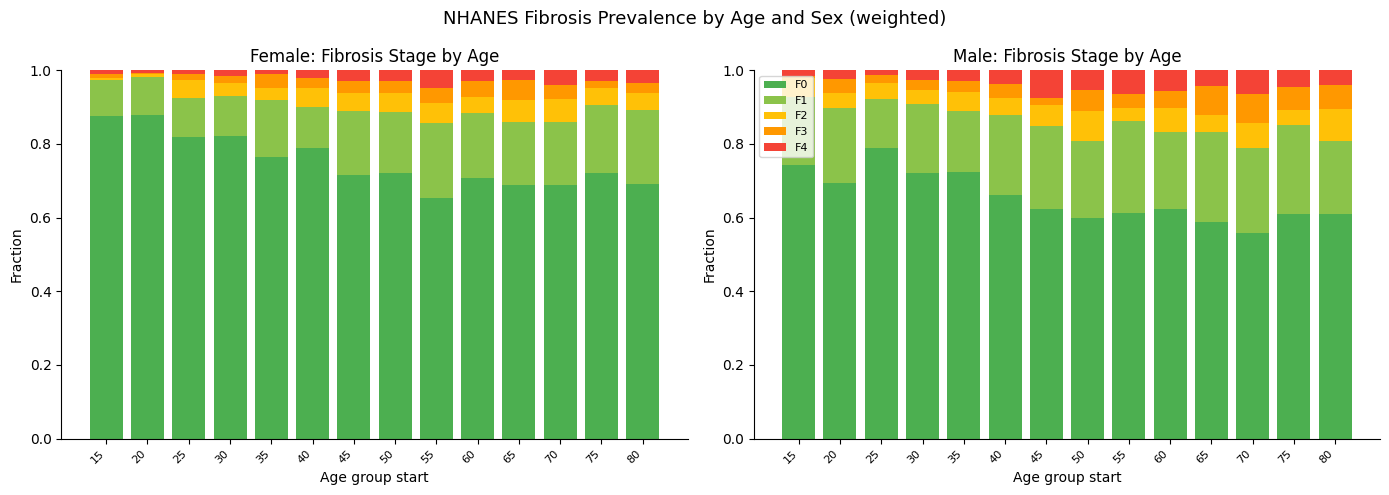

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, sex in zip(axes, ['Female', 'Male']):
    sub = prevalence_df[prevalence_df['sex'] == sex]
    age_labels = sub['age_start'].unique()
    bottom = np.zeros(len(age_labels))

    for stage, color in zip(FIBROSIS_LABELS, FIBROSIS_COLORS):
        vals = sub[sub['stage'] == stage].sort_values('age_start')['fraction'].values
        ax.bar(range(len(age_labels)), vals, bottom=bottom, color=color,
               label=stage, width=0.8)
        bottom += vals

    ax.set_xticks(range(len(age_labels)))
    ax.set_xticklabels([f'{int(a)}' for a in sorted(age_labels)],
                       rotation=45, ha='right', fontsize=8)
    ax.set_xlabel('Age group start')
    ax.set_ylabel('Fraction')
    ax.set_title(f'{sex}: Fibrosis Stage by Age')
    ax.set_ylim(0, 1)
    if sex == 'Male':
        ax.legend(loc='upper left', fontsize=8)
    sns.despine(ax=ax)

plt.suptitle('NHANES Fibrosis Prevalence by Age and Sex (weighted)', fontsize=13)
plt.tight_layout()
plt.show()

## 3. Build Vivarium Artifact with Categorical Risk

For an `ordered_polytomous` distribution, the artifact needs:

| Key | Content |
|-----|---------|
| `risk_factor.fibrosis_stage.distribution` | `"ordered_polytomous"` |
| `risk_factor.fibrosis_stage.exposure` | Category probabilities per age/sex/year |
| `risk_factor.fibrosis_stage.categories` | Map from cat codes to stage names |

The exposure DataFrame is in **long format**: each row has a `parameter`
column (cat1–cat5) and a `value` column (probability). Probabilities must
sum to 1 within each age/sex/year stratum.

Category ordering follows GBD convention:
- cat1 = most exposed (F4, cirrhosis)
- cat5 = unexposed (F0, no fibrosis)

In [4]:
from vivarium.framework.artifact import Artifact
from loguru import logger

logger.disable('vivarium')

YEAR_START = 2024
YEAR_END = 2025
INDEX_COLS = ['sex', 'age_start', 'age_end', 'year_start', 'year_end']
YEAR_BINS = [(2020 + i, 2021 + i) for i in range(11)]


def expand_years(df, year_pairs):
    pieces = []
    for ys, ye in year_pairs:
        chunk = df.copy()
        chunk['year_start'] = ys
        chunk['year_end'] = ye
        pieces.append(chunk)
    return pd.concat(pieces, ignore_index=True).set_index(INDEX_COLS)


# --- Build exposure data (long format with parameter + value columns) ---
exposure_rows = []
for (age_grp, sex), g in nhanes_lsm.groupby(['age_group', 'SEX'], observed=True):
    age_start = int(age_grp.split('-')[0])
    age_end = int(age_grp.split('-')[1])
    fib = weighted_fibrosis_fractions(g['LSM_KPA'].values, g['WEIGHT'].values)
    for stage in FIBROSIS_LABELS:
        exposure_rows.append({
            'sex': sex,
            'age_start': float(age_start),
            'age_end': float(age_end),
            'year_start': YEAR_START,
            'year_end': YEAR_END,
            'parameter': STAGE_TO_CAT[stage],
            'value': fib[stage],
        })

exposure_long = pd.DataFrame(exposure_rows)

# Fill missing age groups (85+) by carrying forward
observed_ages = sorted(exposure_long['age_start'].unique())
all_exposure_rows = []
for sex in ['Female', 'Male']:
    sex_data = exposure_long[exposure_long['sex'] == sex]
    last_fractions = None
    for age_start, age_end in GBD_AGE_BINS:
        match = sex_data[sex_data['age_start'] == age_start]
        if len(match) > 0:
            last_fractions = dict(zip(match['parameter'], match['value']))
            for _, row in match.iterrows():
                all_exposure_rows.append(row.to_dict())
        elif last_fractions is not None:
            for cat, val in last_fractions.items():
                all_exposure_rows.append({
                    'sex': sex,
                    'age_start': float(age_start),
                    'age_end': float(age_end),
                    'year_start': YEAR_START,
                    'year_end': YEAR_END,
                    'parameter': cat,
                    'value': val,
                })

exposure_full = pd.DataFrame(all_exposure_rows)

# Verify probabilities sum to 1
totals = exposure_full.groupby(['sex', 'age_start'])['value'].sum()
assert np.allclose(totals, 1.0), f'Probabilities do not sum to 1: {totals[~np.isclose(totals, 1)]}'

print(f'Exposure data: {len(exposure_full)} rows '
      f'({len(exposure_full) // 5} strata x 5 categories)')
print(f'\nSample (Female 40-45):')
display(exposure_full[
    (exposure_full['sex'] == 'Female') & (exposure_full['age_start'] == 40)
][['parameter', 'value']].assign(
    stage=lambda d: d['parameter'].map(CAT_TO_STAGE)
))

Exposure data: 170 rows (34 strata x 5 categories)

Sample (Female 40-45):


,parameter,value,stage
25,cat5,0.789404,F0
26,cat4,0.110341,F1
27,cat3,0.051218,F2
28,cat2,0.029374,F3
29,cat1,0.019663,F4


In [5]:
# --- Population structure (same as notebook 01) ---
pop_rows = []
for age_start, age_end in GBD_AGE_BINS:
    for sex in ['Female', 'Male']:
        pop_rows.append({
            'age_start': float(age_start), 'age_end': float(age_end),
            'sex': sex, 'year_start': YEAR_START, 'year_end': YEAR_END,
            'value': 1000.0,
        })
pop_structure = pd.DataFrame(pop_rows)

# --- Mortality (placeholder) ---
acmr_rows, tmrle_rows = [], []
for age_start, age_end in GBD_AGE_BINS:
    for sex in ['Female', 'Male']:
        acmr_rows.append({
            'sex': sex, 'age_start': float(age_start),
            'age_end': float(age_end),
            'year_start': YEAR_START, 'year_end': YEAR_END,
            'value': 1e-9,
        })
        tmrle_rows.append({
            'sex': sex, 'age_start': float(age_start),
            'age_end': float(age_end),
            'year_start': YEAR_START, 'year_end': YEAR_END,
            'value': max(100 - age_start, 0.5),
        })
acmr_table = pd.DataFrame(acmr_rows)
tmrle_table = pd.DataFrame(tmrle_rows)

# --- Write artifact ---
ARTIFACT_PATH = os.path.join(OUTPUT_DIR, 'nhanes_fibrosis_categorical.hdf')
if os.path.exists(ARTIFACT_PATH):
    os.remove(ARTIFACT_PATH)

artifact = Artifact(ARTIFACT_PATH)
artifact.write('population.location', 'United States')
artifact.write('population.structure', expand_years(pop_structure, YEAR_BINS))
artifact.write('population.theoretical_minimum_risk_life_expectancy',
               expand_years(tmrle_table, YEAR_BINS))
artifact.write('cause.all_causes.cause_specific_mortality_rate',
               expand_years(acmr_table, YEAR_BINS))

artifact.write('risk_factor.fibrosis_stage.distribution', 'ordered_polytomous')
artifact.write('risk_factor.fibrosis_stage.exposure',
               expand_years(exposure_full, YEAR_BINS))
artifact.write('risk_factor.fibrosis_stage.categories', {
    'cat1': 'F4 (cirrhosis, >=14 kPa)',
    'cat2': 'F3 (advanced fibrosis, 10-14 kPa)',
    'cat3': 'F2 (significant fibrosis, 8-10 kPa)',
    'cat4': 'F1 (mild fibrosis, 6-8 kPa)',
    'cat5': 'F0 (no significant fibrosis, <6 kPa)',
})

print('Artifact contents:')
print(artifact)

Artifact contents:
Artifact containing the following keys:
metadata
	keyspace
population
	location
	structure
	theoretical_minimum_risk_life_expectancy
cause
	all_causes
		cause_specific_mortality_rate
risk_factor
	fibrosis_stage
		distribution
		exposure
		categories



## 4. Run Categorical Simulation

In [6]:
from vivarium import InteractiveContext
from vivarium_public_health.population import BasePopulation
from vivarium_public_health.risks import Risk

sim = InteractiveContext(
    components=[
        BasePopulation(),
        Risk('risk_factor.fibrosis_stage'),
    ],
    configuration={
        'input_data': {
            'artifact_path': os.path.abspath(ARTIFACT_PATH),
        },
        'interpolation': {'order': 0, 'extrapolate': True},
        'randomness': {
            'map_size': 1_000_000,
            'key_columns': ['entrance_time', 'age'],
            'random_seed': 42,
        },
        'time': {
            'start': {'year': YEAR_START, 'month': 1, 'day': 1},
            'end': {'year': YEAR_START, 'month': 7, 'day': 1},
            'step_size': 28,
        },
        'population': {
            'population_size': 10_000,
            'initialization_age_min': 18,
            'initialization_age_max': 95,
        },
    },
)

pop = sim.get_population(['age', 'sex', 'fibrosis_stage.exposure'])
pop = pop.rename(columns={'fibrosis_stage.exposure': 'fibrosis_cat'})

# Map cat codes to stage names
pop['stage'] = pop['fibrosis_cat'].map(CAT_TO_STAGE)

print(f'Simulation: {len(pop)} simulants')
print(f'\nCategory distribution:')
print(pop['stage'].value_counts().sort_index())
print(f'\nFirst 10 simulants:')
display(pop[['age', 'sex', 'stage']].head(10))

Simulation: 10000 simulants

Category distribution:
stage
F0    6890
F1    1784
F2     566
F3     396
F4     364
Name: count, dtype: int64

First 10 simulants:


,age,sex,stage
0,84.227129,Male,F0
1,30.082087,Male,F0
2,35.636718,Male,F0
3,75.514291,Female,F0
4,22.093072,Female,F0
5,45.582160,Male,F0
6,41.821930,Male,F1
7,18.383201,Female,F0
8,69.684707,Female,F1
9,78.596854,Female,F0


## 5. Validate: Categorical Sim vs. NHANES

In [7]:
# Overall fibrosis fractions from simulation
sim_fibrosis = pop['stage'].value_counts(normalize=True).reindex(FIBROSIS_LABELS).fillna(0)

print('Overall fibrosis prevalence comparison:')
print(f'{"Stage":>5}  {"NHANES":>8}  {"Sim":>8}  {"Error":>8}')
for lab in FIBROSIS_LABELS:
    err = sim_fibrosis[lab] - nhanes_fibrosis[lab]
    print(f'{lab:>5}  {nhanes_fibrosis[lab]:>8.2%}  {sim_fibrosis[lab]:>8.2%}  '
          f'{"+" if err >= 0 else ""}{err:>7.2%}')

Overall fibrosis prevalence comparison:
Stage    NHANES       Sim     Error
   F0    70.60%    68.90%   -1.70%
   F1    17.81%    17.84%  +  0.03%
   F2     4.76%     5.66%  +  0.90%
   F3     3.54%     3.96%  +  0.42%
   F4     3.29%     3.64%  +  0.35%


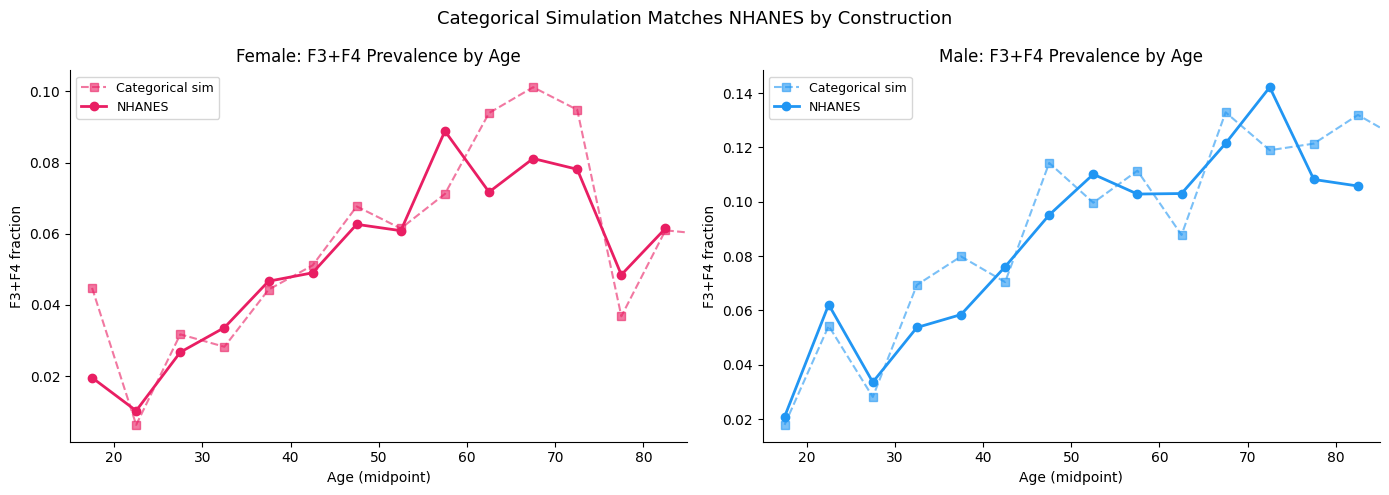

In [8]:
# Per-stratum comparison
pop['age_group'] = pd.cut(
    pop['age'],
    bins=[b[0] for b in GBD_AGE_BINS] + [GBD_AGE_BINS[-1][1]],
    right=False,
    labels=[f'{a}-{b}' for a, b in GBD_AGE_BINS],
)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, sex, color in zip(axes, ['Female', 'Male'], ['#E91E63', '#2196F3']):
    # NHANES stratum fractions
    nhanes_sub = prevalence_df[(prevalence_df['sex'] == sex)
                               & (prevalence_df['stage'].isin(['F3', 'F4']))]
    nhanes_f34 = nhanes_sub.groupby('age_start')['fraction'].sum()

    # Sim stratum fractions
    sim_sub = pop[(pop['sex'] == sex)].copy()
    sim_f34 = sim_sub.groupby('age_group', observed=True)['stage'].apply(
        lambda s: ((s == 'F3') | (s == 'F4')).mean()
    )
    sim_age_starts = [int(x.split('-')[0]) for x in sim_f34.index]

    age_mid_nhanes = nhanes_f34.index + 2.5
    age_mid_sim = [a + 2.5 for a in sim_age_starts]

    ax.errorbar(age_mid_nhanes, nhanes_f34.values, fmt='o-', color=color,
                label='NHANES', capsize=3, linewidth=2)
    ax.plot(age_mid_sim, sim_f34.values, 's--', color=color, alpha=0.6,
            label='Categorical sim')
    ax.set_xlabel('Age (midpoint)')
    ax.set_ylabel('F3+F4 fraction')
    ax.set_title(f'{sex}: F3+F4 Prevalence by Age')
    ax.legend(fontsize=9)
    ax.set_xlim(15, 85)
    sns.despine(ax=ax)

plt.suptitle('Categorical Simulation Matches NHANES by Construction', fontsize=13)
plt.tight_layout()
plt.show()

## 6. Head-to-Head: Categorical vs. Continuous

We load the continuous simulation results from notebook 01's artifact
(lognormal distribution) and compare fibrosis staging accuracy
side by side.

In [9]:
from vivarium_public_health.risks.distributions import ContinuousDistribution

# Patch ContinuousDistribution bug (same as notebook 01)
_original_continuous_setup = ContinuousDistribution.setup

def _fixed_continuous_setup(self, builder):
    _original_continuous_setup(self, builder)
    builder.value.register_attribute_producer(
        self.exposure_params_name, source=self.parameters_table
    )

ContinuousDistribution.setup = _fixed_continuous_setup

# Run continuous simulation using artifact from notebook 01
CONTINUOUS_PATH = os.path.join(OUTPUT_DIR, 'nhanes_liver_stiffness.hdf')
if not os.path.exists(CONTINUOUS_PATH):
    print('Run notebook 01 first to generate the continuous artifact.')
else:
    cont_sim = InteractiveContext(
        components=[
            BasePopulation(),
            Risk('risk_factor.liver_stiffness'),
        ],
        configuration={
            'input_data': {
                'artifact_path': os.path.abspath(CONTINUOUS_PATH),
            },
            'interpolation': {'order': 0, 'extrapolate': True},
            'randomness': {
                'map_size': 1_000_000,
                'key_columns': ['entrance_time', 'age'],
                'random_seed': 42,
            },
            'time': {
                'start': {'year': YEAR_START, 'month': 1, 'day': 1},
                'end': {'year': YEAR_START, 'month': 7, 'day': 1},
                'step_size': 28,
            },
            'population': {
                'population_size': 10_000,
                'initialization_age_min': 18,
                'initialization_age_max': 95,
            },
        },
    )

    cont_pop = cont_sim.get_population(['age', 'sex', 'liver_stiffness.exposure'])
    cont_pop = cont_pop.rename(columns={'liver_stiffness.exposure': 'lsm_kpa'})

    # Derive fibrosis stages from continuous values
    cont_pop['stage'] = pd.cut(
        cont_pop['lsm_kpa'], bins=FIBROSIS_BINS,
        labels=FIBROSIS_LABELS, right=False,
    )
    cont_fibrosis = cont_pop['stage'].value_counts(normalize=True).reindex(
        FIBROSIS_LABELS).fillna(0)

    print('Continuous (lognormal) simulation fibrosis staging:')
    for lab in FIBROSIS_LABELS:
        print(f'  {lab}: {cont_fibrosis[lab]:.2%}')

Continuous (lognormal) simulation fibrosis staging:
  F0: 64.32%
  F1: 13.55%
  F2: 8.24%
  F3: 7.60%
  F4: 6.29%


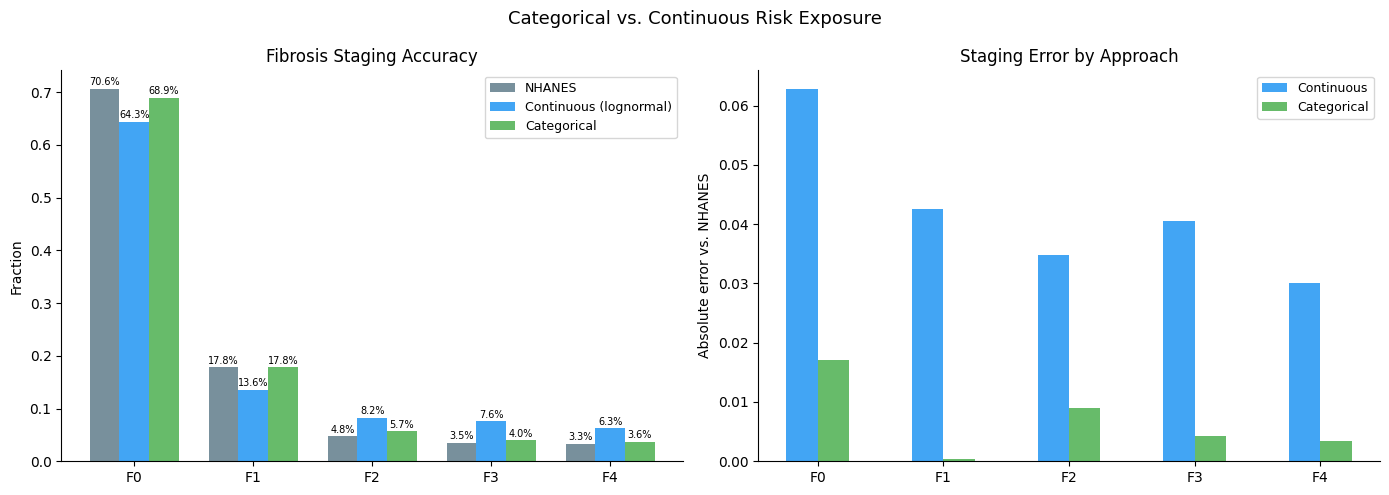

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: fibrosis staging bar chart
ax = axes[0]
x = np.arange(len(FIBROSIS_LABELS))
w = 0.25
ax.bar(x - w, nhanes_fibrosis.values, w,
       label='NHANES', color='#607D8B', alpha=0.85)
ax.bar(x, cont_fibrosis.values, w,
       label='Continuous (lognormal)', color='#2196F3', alpha=0.85)
ax.bar(x + w, sim_fibrosis.values, w,
       label='Categorical', color='#4CAF50', alpha=0.85)
ax.set_xticks(x)
ax.set_xticklabels(FIBROSIS_LABELS)
ax.set_ylabel('Fraction')
ax.set_title('Fibrosis Staging Accuracy')
ax.legend(fontsize=9)
for i in range(len(FIBROSIS_LABELS)):
    for frac, dx in zip(
        [nhanes_fibrosis.values[i], cont_fibrosis.values[i], sim_fibrosis.values[i]],
        [-w, 0, w]):
        ax.text(i + dx, frac + 0.003, f'{frac:.1%}',
                ha='center', va='bottom', fontsize=7)
sns.despine(ax=ax)

# Right: error comparison
ax = axes[1]
cont_err = [cont_fibrosis[lab] - nhanes_fibrosis[lab] for lab in FIBROSIS_LABELS]
cat_err = [sim_fibrosis[lab] - nhanes_fibrosis[lab] for lab in FIBROSIS_LABELS]
ax.bar(x - w/2, [abs(e) for e in cont_err], w,
       label='Continuous', color='#2196F3', alpha=0.85)
ax.bar(x + w/2, [abs(e) for e in cat_err], w,
       label='Categorical', color='#4CAF50', alpha=0.85)
ax.set_xticks(x)
ax.set_xticklabels(FIBROSIS_LABELS)
ax.set_ylabel('Absolute error vs. NHANES')
ax.set_title('Staging Error by Approach')
ax.legend(fontsize=9)
sns.despine(ax=ax)

plt.suptitle('Categorical vs. Continuous Risk Exposure', fontsize=13)
plt.tight_layout()
plt.show()

In [11]:
comp_df = pd.DataFrame({
    'NHANES (weighted)': nhanes_fibrosis,
    'Continuous (lognormal)': cont_fibrosis,
    'Categorical (polytomous)': sim_fibrosis,
}).T
comp_df.columns = FIBROSIS_LABELS

print('Fibrosis staging comparison:')
display(comp_df.style.format('{:.2%}'))

# Absolute errors
err_df = comp_df.copy()
for lab in FIBROSIS_LABELS:
    err_df[lab] = (err_df[lab] - nhanes_fibrosis[lab]).abs()
err_df = err_df.iloc[1:]  # drop NHANES row
err_df['total'] = err_df.sum(axis=1)

print('\nAbsolute errors:')
display(err_df.style.format('{:.3f}').background_gradient(
    subset=['total'], cmap='RdYlGn_r'))

Fibrosis staging comparison:


,F0,F1,F2,F3,F4
NHANES (weighted),70.60%,17.81%,4.76%,3.54%,3.29%
Continuous (lognormal),64.32%,13.55%,8.24%,7.60%,6.29%
Categorical (polytomous),68.90%,17.84%,5.66%,3.96%,3.64%



Absolute errors:


,F0,F1,F2,F3,F4,total
Continuous (lognormal),0.063,0.043,0.035,0.041,0.030,0.211
Categorical (polytomous),0.017,0.000,0.009,0.004,0.003,0.034


## 7. Trajectories: Categories Are Stable Over Time

In the continuous model, a simulant's exposure changes when they cross
age-bin boundaries (the mean/SD of the lognormal changes). In the
categorical model, the **propensity** is fixed but the **category
probabilities** change with age, so a simulant can transition between
fibrosis stages as they age. We track this.

In [12]:
# Track a sample of simulants as they age
tracked = [0, 100, 500, 1000, 2000, 5000, 7500, 9000]

records = []
snap = sim.get_population(['age', 'sex', 'fibrosis_stage.exposure'])
for sid in tracked:
    records.append({
        'simulant': sid, 'time': sim.current_time,
        'age': snap.loc[sid, 'age'], 'sex': snap.loc[sid, 'sex'],
        'stage': CAT_TO_STAGE[snap.loc[sid, 'fibrosis_stage.exposure']],
    })

N_STEPS = 65  # ~5 years
for step in range(N_STEPS):
    sim.step()
    snap = sim.get_population(['age', 'fibrosis_stage.exposure'])
    for sid in tracked:
        records.append({
            'simulant': sid, 'time': sim.current_time,
            'age': snap.loc[sid, 'age'],
            'sex': records[tracked.index(sid)]['sex'],
            'stage': CAT_TO_STAGE[snap.loc[sid, 'fibrosis_stage.exposure']],
        })

traj = pd.DataFrame(records)
print(f'Collected {len(traj)} trajectory points over ~5 years')
print(f'\nTransitions observed:')
for sid in tracked:
    sub = traj[traj['simulant'] == sid]
    stages = sub['stage'].unique()
    age0, age1 = sub['age'].iloc[0], sub['age'].iloc[-1]
    sex = sub['sex'].iloc[0]
    if len(stages) > 1:
        print(f'  #{sid} ({sex}, age {age0:.0f}\u2192{age1:.0f}): '
              f'{", ".join(stages)}')
    else:
        print(f'  #{sid} ({sex}, age {age0:.0f}\u2192{age1:.0f}): '
              f'{stages[0]} (stable)')

Collected 528 trajectory points over ~5 years

Transitions observed:
  #0 (Male, age 84→89): F0 (stable)
  #100 (Male, age 28→33): F0 (stable)
  #500 (Male, age 88→93): F0 (stable)
  #1000 (Female, age 32→37): F0 (stable)
  #2000 (Female, age 95→100): F2 (stable)
  #5000 (Female, age 71→76): F0 (stable)
  #7500 (Female, age 89→94): F0 (stable)
  #9000 (Male, age 21→26): F1, F0


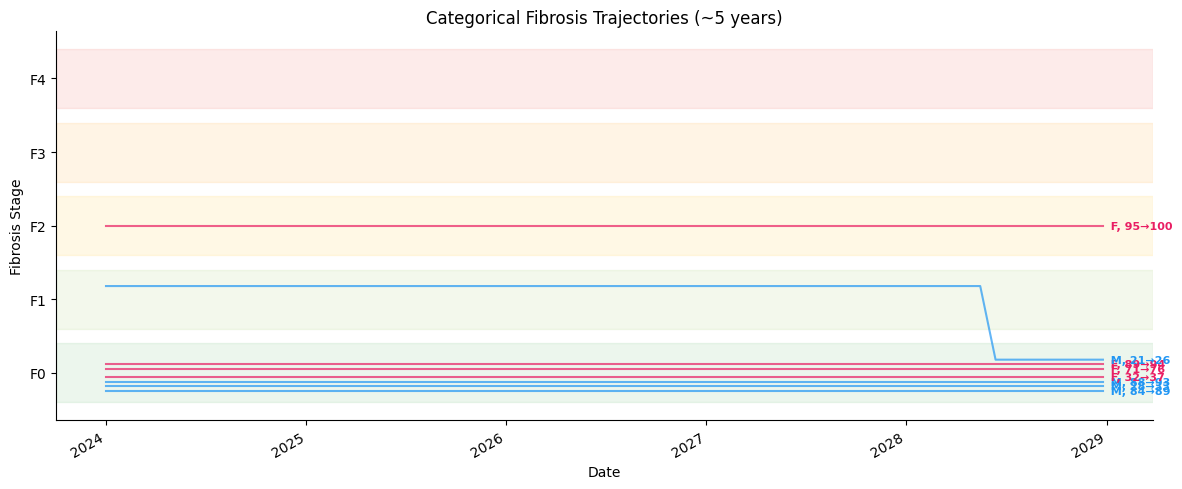

In [13]:
# Visualize categorical trajectories
stage_y = {'F0': 0, 'F1': 1, 'F2': 2, 'F3': 3, 'F4': 4}
colors_sex = {'Female': '#E91E63', 'Male': '#2196F3'}

fig, ax = plt.subplots(figsize=(12, 5))

for i, sid in enumerate(tracked):
    sub = traj[traj['simulant'] == sid]
    sex = sub['sex'].iloc[0]
    age0 = sub['age'].iloc[0]
    age1 = sub['age'].iloc[-1]
    y = sub['stage'].map(stage_y).values + (i - len(tracked)/2) * 0.06
    color = colors_sex[sex]
    ax.plot(sub['time'], y, color=color, alpha=0.7, linewidth=1.5)
    ax.text(sub['time'].iloc[-1], y[-1],
            f'  {sex[0]}, {age0:.0f}\u2192{age1:.0f}',
            color=color, fontsize=8, va='center', fontweight='bold')

ax.set_yticks(range(5))
ax.set_yticklabels(FIBROSIS_LABELS)
ax.set_xlabel('Date')
ax.set_ylabel('Fibrosis Stage')
ax.set_title('Categorical Fibrosis Trajectories (~5 years)')

for stage, color in zip(FIBROSIS_LABELS, FIBROSIS_COLORS):
    y_val = stage_y[stage]
    ax.axhspan(y_val - 0.4, y_val + 0.4, alpha=0.1, color=color)

fig.autofmt_xdate()
sns.despine()
plt.tight_layout()
plt.show()

## 8. Trade-offs: Continuous vs. Categorical

Each approach has strengths and weaknesses. The choice depends on
what matters most for the modeling question.

In [14]:
tradeoffs = pd.DataFrame([
    {'Dimension': 'Fibrosis staging accuracy',
     'Continuous (lognormal)': 'Poor (F4 overestimated ~2x)',
     'Categorical (polytomous)': 'Exact by construction'},
    {'Dimension': 'Granularity',
     'Continuous (lognormal)': 'Full kPa resolution',
     'Categorical (polytomous)': '5 categories only'},
    {'Dimension': 'Within-category variation',
     'Continuous (lognormal)': 'Yes (each simulant has unique kPa)',
     'Categorical (polytomous)': 'No (all F2 simulants are equivalent)'},
    {'Dimension': 'Dose-response modeling',
     'Continuous (lognormal)': 'Natural (RR per unit kPa)',
     'Categorical (polytomous)': 'Requires RR per category'},
    {'Dimension': 'Age-related transitions',
     'Continuous (lognormal)': 'Smooth (PPF shift with age-specific params)',
     'Categorical (polytomous)': 'Discrete jumps between stages'},
    {'Dimension': 'Artifact complexity',
     'Continuous (lognormal)': 'Mean + SD per age/sex bin',
     'Categorical (polytomous)': '5 probabilities per age/sex bin'},
    {'Dimension': 'Distribution fitting',
     'Continuous (lognormal)': 'Required (choice of parametric family)',
     'Categorical (polytomous)': 'Not needed'},
]).set_index('Dimension')

print('Trade-offs between continuous and categorical risk exposure:\n')
display(tradeoffs.style.set_properties(**{'text-align': 'left'}))

Trade-offs between continuous and categorical risk exposure:



,Continuous (lognormal),Categorical (polytomous)
Dimension,,
Fibrosis staging accuracy,Poor (F4 overestimated ~2x),Exact by construction
Granularity,Full kPa resolution,5 categories only
Within-category variation,Yes (each simulant has unique kPa),No (all F2 simulants are equivalent)
Dose-response modeling,Natural (RR per unit kPa),Requires RR per category
Age-related transitions,Smooth (PPF shift with age-specific params),Discrete jumps between stages
Artifact complexity,Mean + SD per age/sex bin,5 probabilities per age/sex bin
Distribution fitting,Required (choice of parametric family),Not needed


## Summary

The categorical approach matches NHANES fibrosis prevalence exactly
because the input probabilities come directly from the weighted
survey data -- no distribution fitting step can introduce error.

The trade-off is resolution: continuous exposures allow dose-response
modeling and within-category variation, while categorical exposures
treat all simulants in the same stage as identical. For disease models
where the key risk factor operates through discrete clinical thresholds
(e.g., cirrhosis diagnosis triggers different treatment pathways),
the categorical approach may be more appropriate. For models that need
to capture the continuous relationship between liver stiffness and
outcomes, the continuous approach -- perhaps with the log transform
explored in notebook 02 -- is the better choice.